Purpose: Find any intersecting genes between the maSigPro time-clustered genes and the HEB genes.<br>
Author: Anna Pardo<br>
Date initiated: Jan. 4, 2026

In [96]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
# load the HEB data
degs = pd.read_csv("../heb_deseq_outfiles/degs_HEB_subgenome_genotype.txt",sep="\t",header="infer")
degs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,Contrast
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa
1,207.226297,-0.439708,0.051274,-8.575620,9.855403e-18,3.173239e-17,recip_syn3,18_aloifolia-V-18_filamentosa
2,43.434762,0.296161,0.075634,3.915737,9.012834e-05,1.581721e-04,recip_syn4,18_aloifolia-V-18_filamentosa
3,52.217998,-1.228132,0.071797,-17.105673,1.346365e-65,1.336024e-64,recip_syn5,18_aloifolia-V-18_filamentosa
4,390.928299,-0.320403,0.054729,-5.854366,4.788330e-09,1.078159e-08,recip_syn7,18_aloifolia-V-18_filamentosa


In [3]:
# load syntelog data
syn = pd.read_csv("../../yucca_synteny/reciprocal_syntelogs_sameinYaYf.txt",sep="\t",header="infer")
syn.head()

,Yf_GeneID,Ya_GeneID,syntelogID
0,YufilH1000002m.g,Yucal.01G000100.v2.1,recip_syn1
1,YufilH1000007m.g,Yucal.01G000200.v2.1,recip_syn2
2,YufilH1000011m.g,Yucal.01G000400.v2.1,recip_syn3
3,YufilH1000013m.g,Yucal.01G000500.v2.1,recip_syn4
4,YufilH1000018m.g,Yucal.01G000600.v2.1,recip_syn5


In [4]:
degs.rename(columns={"GeneID":"syntelogID"},inplace=True)
degs = degs.merge(syn)
degs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
1,67.211469,0.918770,0.064924,14.151414,1.830403e-45,1.182459e-44,recip_syn2,2AB_aloifolia-V-2AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
2,67.211469,0.878624,0.070650,12.436335,1.659451e-35,1.027305e-34,recip_syn2,1AB_aloifolia-V-1AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
3,67.211469,1.056236,0.085789,12.311974,7.808925e-35,7.650846e-34,recip_syn2,19_aloifolia-V-19_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1
4,67.211469,0.779668,0.146913,5.307008,1.114394e-07,5.424920e-07,recip_syn2,15_aloifolia-V-15_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1


In [5]:
# set a Genotype column in degs
gt = {}
for i in list(degs["Contrast"].unique()):
    gt[i] = i.split("_")[0]
degs["genotype"] = degs["Contrast"].map(gt)

In [6]:
degs.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,syntelogID,Contrast,Yf_GeneID,Ya_GeneID,genotype
0,67.211469,0.846089,0.063095,13.409767,5.300490e-41,3.217773e-40,recip_syn2,18_aloifolia-V-18_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,18
1,67.211469,0.918770,0.064924,14.151414,1.830403e-45,1.182459e-44,recip_syn2,2AB_aloifolia-V-2AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,2AB
2,67.211469,0.878624,0.070650,12.436335,1.659451e-35,1.027305e-34,recip_syn2,1AB_aloifolia-V-1AB_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,1AB
3,67.211469,1.056236,0.085789,12.311974,7.808925e-35,7.650846e-34,recip_syn2,19_aloifolia-V-19_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,19
4,67.211469,0.779668,0.146913,5.307008,1.114394e-07,5.424920e-07,recip_syn2,15_aloifolia-V-15_filamentosa,YufilH1000007m.g,Yucal.01G000200.v2.1,15


In [7]:
bias = []
for i in list(degs["log2FoldChange"]):
    if i<0:
        bias.append("Ya")
    elif i>0:
        bias.append("Yf")
degs["Bias"] = bias

In [8]:
# load CAM gene annotations
cam = pd.read_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")

In [58]:
# define a function to load & summarize the data for a given genotype
def load_sum_gt(gt):
    if gt in ["all","gt37"]:
        if gt=="all":
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_18-Nov.tsv",sep="\t",header="infer")
            gtc["genotype"] = gt
        else:
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_17-Nov.tsv",sep="\t",header="infer")
            gtc["genotype"] = gt.lstrip("gt")
    else:
        gtc = pd.read_csv("./Yg"+gt+"_hclust_k6_clusters.txt",sep="\t",header="infer")
        gtc["genotype"] = gt
        
    # add subgenome to gtc
    sg = []
    for i in gtc["GeneID"]:
        if i.startswith("Yucal"):
            sg.append("Ya")
        else:
            sg.append("Yf")
    gtc["Bias"] = sg
        
    sum1 = gtc.groupby(["cluster","Bias"]).count()[["GeneID"]].reset_index().rename(columns={"GeneID":"n_genes"})
    sum1["genotype"] = gt
    gtcam = cam.merge(gtc)
    camsum = gtcam.groupby("cluster").count().reset_index()[["cluster","GeneID"]].rename(columns={"GeneID":"n_genes_"+gt})
    d = {"clusters":gtc,"CAMgenes":gtcam,"all_summary":sum1,"CAM_summary":camsum}
    #d = {"clusters":gtc,"CAMgenes":gtcam}
    return d

In [59]:
# instead of loading them one at a time: set up a dict of dicts
allgt = {}
for f in os.listdir("./"):
    if f.startswith("Yg"):
        g = f.split("_")[0].lstrip("Yg")
        allgt[g] = load_sum_gt(g)
    elif f.startswith("hck6"):
        g = f.split("_")[2]
        df = load_sum_gt(g)
        if g=="gt37":
            g = g.lstrip("gt")
        allgt[g] = df

In [51]:
allgt["37"]["clusters"].head()

,cluster,GeneID,genotype,Bias
0,1,Yucal.01G000100.v2.1,37,Ya
1,2,Yucal.01G000200.v2.1,37,Ya
2,3,Yucal.01G000400.v2.1,37,Ya
3,2,Yucal.01G000500.v2.1,37,Ya
4,4,Yucal.01G000600.v2.1,37,Ya


In [40]:
subheb = degs[["genotype","Ya_GeneID","Yf_GeneID","Bias","padj","log2FoldChange"]]

In [41]:
# wrangle HEB data so as to have columns: genotype, bias, GeneID
yaheb = subheb[subheb["Bias"]=="Ya"].drop("Yf_GeneID",axis=1).rename(columns={"Ya_GeneID":"GeneID"})
yfheb = subheb[subheb["Bias"]=="Yf"].drop("Ya_GeneID",axis=1).rename(columns={"Yf_GeneID":"GeneID"})
yfheb.head()

,genotype,GeneID,Bias,padj,log2FoldChange
0,18,YufilH1000007m.g,Yf,3.217773e-40,0.846089
1,2AB,YufilH1000007m.g,Yf,1.182459e-44,0.918770
2,1AB,YufilH1000007m.g,Yf,1.027305e-34,0.878624
3,19,YufilH1000007m.g,Yf,7.650846e-34,1.056236
4,15,YufilH1000007m.g,Yf,5.424920e-07,0.779668


In [42]:
allheb = pd.concat([yaheb,yfheb])

In [43]:
# make a function to find the time-structured genes that also exhibit HEB (for a given genotype)
def find_gt_int(gt):
    tcgenes = allgt[gt]["clusters"]
    heb = allheb[allheb["genotype"]==gt]
    intdf = heb.merge(tcgenes)
    return intdf

In [44]:
dflist = []
for g in allheb["genotype"].unique():
    if g in allgt.keys():
        dflist.append(find_gt_int(g))

In [45]:
tcheb = pd.concat(dflist)

In [46]:
tcheb.head()

,genotype,GeneID,Bias,padj,log2FoldChange,cluster
0,18,Yucal.01G001000.v2.1,Ya,1.078159e-08,-0.320403,3
1,18,Yucal.01G002600.v2.1,Ya,7.675298e-03,-0.307133,2
2,18,Yucal.01G003400.v2.1,Ya,9.726598e-58,-1.079681,4
3,18,Yucal.01G004500.v2.1,Ya,5.151938e-13,-1.209836,5
4,18,Yucal.01G004800.v2.1,Ya,1.344302e-12,-1.607259,1


In [47]:
sum_tcheb = tcheb.groupby(["genotype","Bias"]).count()[["GeneID"]].reset_index()

In [60]:
# get out all summary data (all genotypes)
## this will help us calculate the % of time-structured genes that exhibit HEB (and % HEB genes that are time-structured)
dflist = []
for k,v in allgt.items():
    dflist.append(v["all_summary"])
allsum = pd.concat(dflist)
allsum.head()

,cluster,Bias,n_genes,genotype
0,1,Ya,535,G
1,1,Yf,444,G
2,2,Ya,491,G
3,2,Yf,423,G
4,3,Ya,276,G


In [61]:
sum_tcheb.head()

,genotype,Bias,GeneID
0,13,Ya,558
1,13,Yf,561
2,18,Ya,4236
3,18,Yf,4018
4,19,Ya,1843


In [62]:
totaltc = allsum.groupby(["genotype","Bias"]).sum()[["n_genes"]].reset_index().rename(columns={"n_genes":"total_tc_genes"})

In [63]:
totaltc.head()

,genotype,Bias,total_tc_genes
0,13,Ya,1983
1,13,Yf,1907
2,18,Ya,12357
3,18,Yf,11769
4,19,Ya,5757


In [64]:
allheb.head()

,genotype,GeneID,Bias,padj,log2FoldChange
21,18,Yucal.01G000400.v2.1,Ya,3.173239e-17,-0.439708
22,2AB,Yucal.01G000400.v2.1,Ya,3.544129e-12,-0.357184
23,1AB,Yucal.01G000400.v2.1,Ya,3.979069e-10,-0.354689
24,19,Yucal.01G000400.v2.1,Ya,5.394027e-07,-0.408195
25,15,Yucal.01G000400.v2.1,Ya,1.561255e-05,-0.595246


In [66]:
# count up total HEB genes in each genotype (for each bias)
hebtotals = allheb.groupby(["genotype","Bias"]).count()[["GeneID"]].reset_index().rename(columns={"GeneID":"total_heb_genes"})
hebtotals.head()

,genotype,Bias,total_heb_genes
0,13,Ya,8767
1,13,Yf,8718
2,15,Ya,6693
3,15,Yf,6476
4,18,Ya,9695


In [67]:
totals = totaltc.merge(hebtotals)
totals.head()

,genotype,Bias,total_tc_genes,total_heb_genes
0,13,Ya,1983,8767
1,13,Yf,1907,8718
2,18,Ya,12357,9695
3,18,Yf,11769,9807
4,19,Ya,5757,8751


In [68]:
sum_tcheb = sum_tcheb.merge(totals)
sum_tcheb.head()

,genotype,Bias,GeneID,total_tc_genes,total_heb_genes
0,13,Ya,558,1983,8767
1,13,Yf,561,1907,8718
2,18,Ya,4236,12357,9695
3,18,Yf,4018,11769,9807
4,19,Ya,1843,5757,8751


In [69]:
sum_tcheb["percent_biased_in_tc"] = (sum_tcheb["GeneID"]/sum_tcheb["total_tc_genes"])*100
sum_tcheb["percent_tc_in_heb"] = (sum_tcheb["GeneID"]/sum_tcheb["total_heb_genes"])*100
sum_tcheb.head()

,genotype,Bias,GeneID,total_tc_genes,total_heb_genes,percent_biased_in_tc,percent_tc_in_heb
0,13,Ya,558,1983,8767,28.139183,6.364777
1,13,Yf,561,1907,8718,29.417934,6.434962
2,18,Ya,4236,12357,9695,34.280165,43.692625
3,18,Yf,4018,11769,9807,34.140539,40.970735
4,19,Ya,1843,5757,8751,32.013201,21.060450


In [70]:
sum_tcheb = sum_tcheb.sort_values(by=["genotype","Bias"],ascending=True).rename(columns={"Bias":"subgenome"})
sum_tcheb.head()

,genotype,subgenome,GeneID,total_tc_genes,total_heb_genes,percent_biased_in_tc,percent_tc_in_heb
0,13,Ya,558,1983,8767,28.139183,6.364777
1,13,Yf,561,1907,8718,29.417934,6.434962
2,18,Ya,4236,12357,9695,34.280165,43.692625
3,18,Yf,4018,11769,9807,34.140539,40.970735
4,19,Ya,1843,5757,8751,32.013201,21.060450


In [77]:
# split by subgenome for test plotting
l = []
for i in ["Ya","Yf"]:
    df = sum_tcheb[sum_tcheb["subgenome"]==i].drop(["GeneID","total_tc_genes","total_heb_genes","subgenome"],axis=1)
    df.rename(columns={"percent_biased_in_tc":"%bias_in_tc_"+i,"percent_tc_in_heb":"%tc_in_heb_"+i},inplace=True)
    l.append(df)
plot = l[0].merge(l[1],)
plot.head()

,genotype,%bias_in_tc_Ya,%tc_in_heb_Ya,%bias_in_tc_Yf,%tc_in_heb_Yf
0,13,28.139183,6.364777,29.417934,6.434962
1,18,34.280165,43.692625,34.140539,40.970735
2,19,32.013201,21.060450,30.127111,18.772905
3,1AB,34.654757,36.251969,33.727556,33.312095
4,2AB,35.257831,60.540930,34.655413,56.050498


In [79]:
len(plot.index)

19

In [97]:
# add CAM physiology & SNP PCA group annotation
physcat = json.load(open("../../phys_figures/physiological_CAM_categories.json"))

In [98]:
snppca = json.load(open("../../genotypes_by_SNP_PCA.json"))
spca2 = {}
for k,v in snppca.items():
    spca2[k] = []
    for i in v:
        if i!="YGG":
            spca2[k].append(i.lstrip("YG"))
        else:
            spca2[k].append("G")

In [100]:
# reverse spca2 (key=genotype, value=PCA-set)
revspca2 = {}
for k,v in spca2.items():
    for i in v:
        revspca2[i] = k

In [101]:
plot["SNP PCA group"] = plot["genotype"].map(revspca2)
plot

,genotype,%bias_in_tc_Ya,%tc_in_heb_Ya,%bias_in_tc_Yf,%tc_in_heb_Yf,SNP PCA group
0,13,28.139183,6.364777,29.417934,6.434962,middle
1,18,34.280165,43.692625,34.140539,40.970735,bottom
2,19,32.013201,21.060450,30.127111,18.772905,bottom
3,1AB,34.654757,36.251969,33.727556,33.312095,top
4,2AB,35.257831,60.540930,34.655413,56.050498,top
5,36,34.937598,48.290466,34.974215,46.058860,middle
6,43,32.131468,62.060401,31.878839,60.795799,bottom
7,45,30.218330,28.482587,30.682111,27.320651,top
8,46,31.040956,20.658717,29.601449,18.903286,bottom
9,48,18.520626,10.464556,17.865429,10.495826,bottom


In [102]:
plot["CAM physiology"] = plot["genotype"].map(physcat)
plot

,genotype,%bias_in_tc_Ya,%tc_in_heb_Ya,%bias_in_tc_Yf,%tc_in_heb_Yf,SNP PCA group,CAM physiology
0,13,28.139183,6.364777,29.417934,6.434962,middle,C3
1,18,34.280165,43.692625,34.140539,40.970735,bottom,C3
2,19,32.013201,21.060450,30.127111,18.772905,bottom,facultative_CAM
3,1AB,34.654757,36.251969,33.727556,33.312095,top,possible_fac_CAM
4,2AB,35.257831,60.540930,34.655413,56.050498,top,possible_fac_CAM
5,36,34.937598,48.290466,34.974215,46.058860,middle,C3
6,43,32.131468,62.060401,31.878839,60.795799,bottom,facultative_CAM
7,45,30.218330,28.482587,30.682111,27.320651,top,C3
8,46,31.040956,20.658717,29.601449,18.903286,bottom,possible_fac_CAM
9,48,18.520626,10.464556,17.865429,10.495826,bottom,facultative_CAM


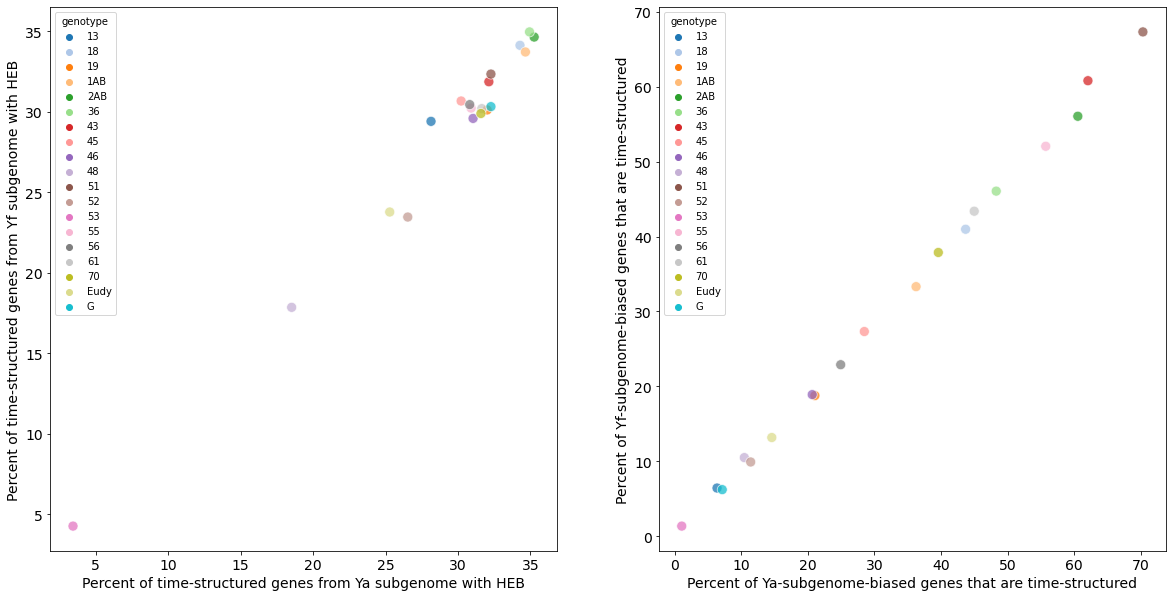

In [93]:
# let's try something real quick...
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,10))
sns.scatterplot(ax=ax[0],data=plot,y="%bias_in_tc_Yf",x="%bias_in_tc_Ya",hue="genotype",palette="tab20",s=100,alpha=0.75)
sns.scatterplot(ax=ax[1],data=plot,y="%tc_in_heb_Yf",x="%tc_in_heb_Ya",hue="genotype",palette="tab20",s=100,alpha=0.75)

ax[0].set_xlabel("Percent of time-structured genes from Ya subgenome with HEB",fontsize=14)
ax[0].set_ylabel("Percent of time-structured genes from Yf subgenome with HEB",fontsize=14)
ax[0].tick_params(axis="both",labelsize=14)

ax[1].set_xlabel("Percent of Ya-subgenome-biased genes that are time-structured",fontsize=14)
ax[1].set_ylabel("Percent of Yf-subgenome-biased genes that are time-structured",fontsize=14)
ax[1].tick_params(axis="both",labelsize=14)

plt.savefig("./timeclustered_heb_percentages.png",dpi=200,bbox_inches="tight")
plt.savefig("./timeclustered_heb_percentages.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./timeclustered_heb_percentages.svg",dpi=200,bbox_inches="tight")

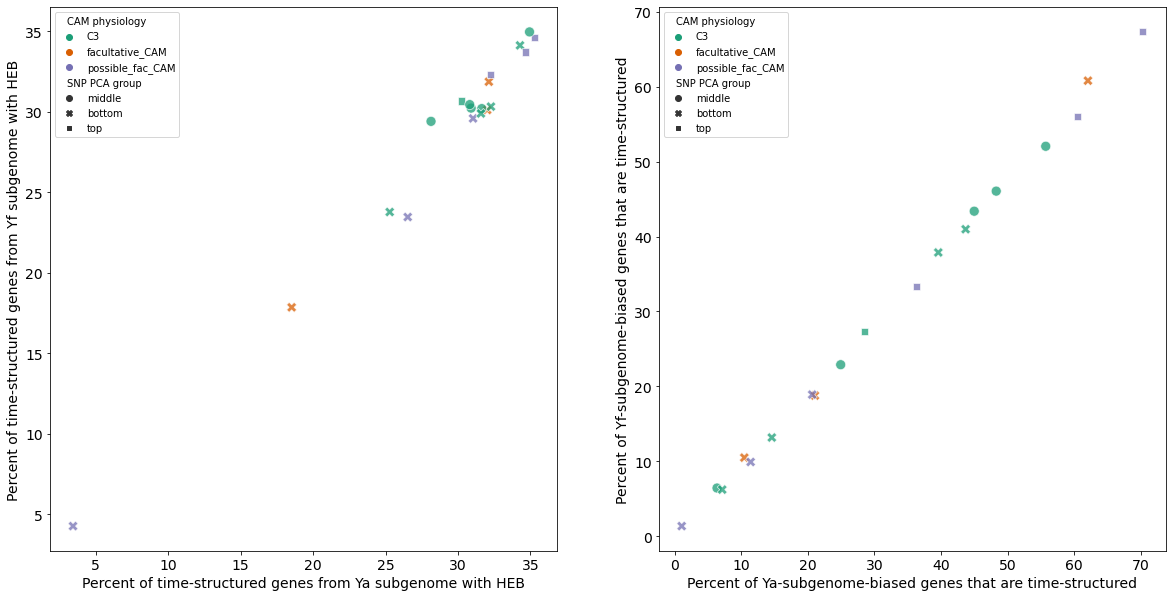

In [106]:
# re-make this plot with physiology & SNP PCA information
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,10))
sns.scatterplot(ax=ax[0],data=plot,y="%bias_in_tc_Yf",x="%bias_in_tc_Ya",hue="CAM physiology",palette="Dark2",
                style="SNP PCA group",s=100,alpha=0.75)
sns.scatterplot(ax=ax[1],data=plot,y="%tc_in_heb_Yf",x="%tc_in_heb_Ya",hue="CAM physiology",palette="Dark2",
                style="SNP PCA group",s=100,alpha=0.75)

ax[0].set_xlabel("Percent of time-structured genes from Ya subgenome with HEB",fontsize=14)
ax[0].set_ylabel("Percent of time-structured genes from Yf subgenome with HEB",fontsize=14)
ax[0].tick_params(axis="both",labelsize=14)

ax[1].set_xlabel("Percent of Ya-subgenome-biased genes that are time-structured",fontsize=14)
ax[1].set_ylabel("Percent of Yf-subgenome-biased genes that are time-structured",fontsize=14)
ax[1].tick_params(axis="both",labelsize=14)

plt.savefig("./timeclustered_heb_percentages_replot.png",dpi=200,bbox_inches="tight")
plt.savefig("./timeclustered_heb_percentages_replot.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./timeclustered_heb_percentages_replot.svg",dpi=200,bbox_inches="tight")

In [94]:
sum_tcheb.sort_values(by="percent_biased_in_tc",ascending=True)

,genotype,subgenome,GeneID,total_tc_genes,total_heb_genes,percent_biased_in_tc,percent_tc_in_heb
24,53,Ya,72,2099,6769,3.430205,1.063673
25,53,Yf,87,2034,6418,4.277286,1.355562
19,48,Yf,616,3448,5869,17.865429,10.495826
18,48,Ya,651,3515,6221,18.520626,10.464556
23,52,Yf,708,3016,7143,23.474801,9.911802
35,Eudy,Yf,1020,4288,7742,23.787313,13.174890
34,Eudy,Ya,1159,4583,7945,25.289112,14.587791
22,52,Ya,839,3162,7350,26.533839,11.414966
0,13,Ya,558,1983,8767,28.139183,6.364777
1,13,Yf,561,1907,8718,29.417934,6.434962


In [95]:
sum_tcheb.sort_values(by="percent_tc_in_heb",ascending=True)

,genotype,subgenome,GeneID,total_tc_genes,total_heb_genes,percent_biased_in_tc,percent_tc_in_heb
24,53,Ya,72,2099,6769,3.430205,1.063673
25,53,Yf,87,2034,6418,4.277286,1.355562
37,G,Yf,546,1800,8773,30.333333,6.223641
0,13,Ya,558,1983,8767,28.139183,6.364777
1,13,Yf,561,1907,8718,29.417934,6.434962
36,G,Ya,640,1983,8956,32.274332,7.146047
23,52,Yf,708,3016,7143,23.474801,9.911802
18,48,Ya,651,3515,6221,18.520626,10.464556
19,48,Yf,616,3448,5869,17.865429,10.495826
22,52,Ya,839,3162,7350,26.533839,11.414966
